# ORAS5 Annual Cell-Year Classification

This notebook builds on the earlier ORAS5 classification test, but instead of using basin-mean monthly values or annual values, it works with **seasonal values at every grid cell**.

The aim is to see whether local ocean variables from ORAS5 can be used to distinguish between two climate regimes:

0 = before the threshold year  
1 = after the threshold year

The workflow is roughly:

1. Load and inspect the ORAS5 files
2. Build annual fields for each variable
3. Combine them into a single feature dataset
4. Convert the dataset into a machine-learning table
5. Train a classifier
6. Evaluate how well it separates the two regimes
7. Explore the data using correlations, distributions and trends

For now the analysis is restricted to a smaller North Atlantic region to compare the result with the previous notebook.

## Imports

Import the packages needed for working with NetCDF files, data handling, plotting, and machine learning.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

## Data Setup

Define the main settings used throughout the notebook:

• the directory containing the ORAS5 boxed files  
• the study region  
• the year used to split the two regimes  
• a folder where plots will be saved

A small helper function is also set up to keep track of plots produced in the notebook.

In [2]:
DATA_DIR = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")

# Region
REGION = {
    "lat_min": 45,
    "lat_max": 65,
    "lon_min": -60,
    "lon_max": -20,
}

MID_YEAR = 1985
MAX_YEARS = None   # for fast testing

OUT_DIR = Path("meeting_outputs")
OUT_DIR.mkdir(exist_ok=True)

NOTEBOOK_NAME = "oras5_annual_cell_year_meeting_version"

PLOT_LOG = []

def save_and_register(fig, name, section, notes=""):
    path = OUT_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    PLOT_LOG.append({
        "notebook": NOTEBOOK_NAME,
        "section": section,
        "plot_name": name,
        "path": str(path),
        "notes": notes,
    })
    print(f"Saved: {path}")

## Variable Configuration

Define which variables will be used as features in the model.

For each variable I specify:

• the token used to identify its files  
• whether the annual value should be calculated as a mean or sum  
• whether depth averaging is needed

The variables included are:

SST  
salinity  
potential temperature  
net heat flux  
zonal current  
meridional current

In [3]:
FILE_RE = re.compile(r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$")

VAR_META = {
    "sst": {
        "token": "sst",
        "agg": "mean",
        "depth_mode": None,
        "kind": "scalar",
    },
    "salinity": {
        "token": "so_salinity",
        "agg": "mean",
        "depth_mode": "0_100m",
        "kind": "scalar",
    },
    "thetao": {
        "token": "thetao",
        "agg": "mean",
        "depth_mode": "0_100m",
        "kind": "scalar",
    },
    "qnet": {
        "token": "heat",
        "agg": "sum",
        "depth_mode": None,
        "kind": "scalar",
    },
    "u_current": {
        "token": "u",
        "agg": "mean",
        "depth_mode": "0_100m",
        "kind": "scalar",
    },
    "v_current": {
        "token": "v",
        "agg": "mean",
        "depth_mode": "0_100m",
        "kind": "scalar",
    },
}

## Finding Files and Reading Dates

These helper functions locate files for each variable and extract the year and month from the filenames.

This information is later used to build the annual datasets.

In [4]:
def files_for_token(data_dir, token):
    all_nc = sorted(data_dir.rglob("*.nc"))
    out = [p for p in all_nc if FILE_RE.search(p.name) and token in p.name]
    return sorted(out)

def time_from_filename(path):
    m = FILE_RE.search(path.name)
    if m is None:
        raise ValueError(f"Filename does not match expected pattern: {path.name}")
    year = int(m.group(1))
    month = int(m.group(2))
    return pd.Timestamp(year=year, month=month, day=1)

## Quick File Check

Before doing anything heavy, check how many files are found for each variable token.

This just confirms that the filename matching is working correctly.

In [5]:
for name, meta in VAR_META.items():
    if meta["kind"] == "scalar":
        paths = files_for_token(DATA_DIR, meta["token"])
        print(f"{name:15s} -> {len(paths)} files using token '{meta['token']}'")
        if len(paths) > 0:
            print("   first:", paths[0].name)
    else:
        upaths = files_for_token(DATA_DIR, meta["u_token"])
        vpaths = files_for_token(DATA_DIR, meta["v_token"])
        print(f"{name:15s} -> {len(upaths)} u-files ('{meta['u_token']}'), {len(vpaths)} v-files ('{meta['v_token']}')")
        if len(upaths) > 0:
            print("   u first:", upaths[0].name)
        if len(vpaths) > 0:
            print("   v first:", vpaths[0].name)

sst             -> 708 files using token 'sst'
   first: ORAS5_1958_01_sst_boxed.nc
salinity        -> 705 files using token 'so_salinity'
   first: ORAS5_1958_01_so_salinity_boxed.nc
thetao          -> 706 files using token 'thetao'
   first: ORAS5_1958_01_thetao_potential_temperature_boxed.nc
qnet            -> 707 files using token 'heat'
   first: ORAS5_1958_01_net_downward_heat_flux_boxed.nc
u_current       -> 2618 files using token 'u'
   first: ORAS5_1958_01_net_downward_heat_flux_boxed.nc
v_current       -> 1211 files using token 'v'
   first: ORAS5_1958_01_meridional_velocity_boxed.nc


## Inspecting Example Files

Look at one example file for each variable to see:

• variable names  
• coordinate names  
• dataset dimensions

ORAS5 files sometimes use slightly different dimension names, so this step helps avoid problems later.

In [6]:
def inspect_file(path):
    with xr.open_dataset(path) as ds:
        print(f"\nFILE: {path.name}")
        print("dims:", dict(ds.dims))
        print("coords:", list(ds.coords))
        print("data_vars:", list(ds.data_vars))
        for name in list(ds.data_vars)[:5]:
            da = ds[name]
            print(f"  {name}: dims={da.dims}, shape={da.shape}")

for name, meta in VAR_META.items():
    if meta["kind"] == "scalar":
        paths = files_for_token(DATA_DIR, meta["token"])
        if paths:
            inspect_file(paths[0])
    else:
        upaths = files_for_token(DATA_DIR, meta["u_token"])
        vpaths = files_for_token(DATA_DIR, meta["v_token"])
        if upaths:
            inspect_file(upaths[0])
        if vpaths:
            inspect_file(vpaths[0])


FILE: ORAS5_1958_01_sst_boxed.nc
dims: {'time_counter': 1, 'y': 522, 'x': 363}
coords: ['nav_lat', 'nav_lon', 'time_counter']
data_vars: ['sosstsst']
  sosstsst: dims=('time_counter', 'y', 'x'), shape=(1, 522, 363)

FILE: ORAS5_1958_01_so_salinity_boxed.nc
dims: {'time_counter': 1, 'deptht': 75, 'y': 522, 'x': 363}
coords: ['deptht', 'nav_lat', 'nav_lon', 'time_counter']
data_vars: ['vosaline']
  vosaline: dims=('time_counter', 'deptht', 'y', 'x'), shape=(1, 75, 522, 363)

FILE: ORAS5_1958_01_thetao_potential_temperature_boxed.nc
dims: {'time_counter': 1, 'deptht': 75, 'y': 522, 'x': 363}
coords: ['deptht', 'nav_lat', 'nav_lon', 'time_counter']
data_vars: ['votemper']
  votemper: dims=('time_counter', 'deptht', 'y', 'x'), shape=(1, 75, 522, 363)

FILE: ORAS5_1958_01_net_downward_heat_flux_boxed.nc
dims: {'time_counter': 1, 'y': 522, 'x': 363}
coords: ['nav_lat', 'nav_lon', 'time_counter']
data_vars: ['sohefldo']
  sohefldo: dims=('time_counter', 'y', 'x'), shape=(1, 522, 363)

FILE: O

## Helper Functions

Define several small functions used later when building the datasets.

These handle:

• identifying the main variable in a file  
• finding coordinate names  
• subsetting the region  
• handling depth dimensions  
• standardising time coordinates

In [7]:
def find_main_var(ds):
    ignore = {
        "time", "time_counter", "valid_time", "nav_time",
        "lat", "lon", "latitude", "longitude", "nav_lat", "nav_lon",
        "depth", "deptht", "depthu", "depthv", "nav_lev"
    }
    candidates = [k for k in ds.data_vars if k not in ignore]
    if len(candidates) == 0:
        raise ValueError(f"No usable data variable found. data_vars={list(ds.data_vars)}")
    return candidates[0]

def find_coord_name(ds, options):
    for name in options:
        if name in ds.coords or name in ds.variables:
            return name
    return None

def normalise_longitude(lon):
    return xr.where(lon > 180, lon - 360, lon)

def subset_region(ds, region):
    lat_name = find_coord_name(ds, ["lat", "latitude", "nav_lat"])
    lon_name = find_coord_name(ds, ["lon", "longitude", "nav_lon"])

    if lat_name is None or lon_name is None:
        print("Warning: could not find lat/lon coords; skipping regional subset")
        return ds

    lat = ds[lat_name]
    lon = ds[lon_name]
    lon = normalise_longitude(lon)

    if lon_name in ds.coords:
        ds = ds.assign_coords({lon_name: lon})

    mask = (
        (lat >= region["lat_min"]) & (lat <= region["lat_max"]) &
        (lon >= region["lon_min"]) & (lon <= region["lon_max"])
    )
    return ds.where(mask, drop=True)

def depth_reduce_if_needed(da, ds, depth_mode):
    if depth_mode is None:
        return da

    for zname in ["depth", "deptht", "depthu", "depthv", "nav_lev"]:
        if zname in da.dims:
            # Try to get the depth coordinate from the DataArray first
            if zname in da.coords:
                z = da[zname]
            elif zname in ds.coords:
                z = ds[zname]
            elif zname in ds.variables:
                z = ds[zname]
            else:
                # if the dim exists but no coord is found then fallback to index positions
                z = xr.DataArray(np.arange(da.sizes[zname]), dims=[zname], coords={zname: np.arange(da.sizes[zname])})

            if depth_mode == "0_100m":
                da = da.where((z >= 0) & (z <= 100), drop=True).mean(dim=zname)
                return da

    return da

def rename_time_dim_if_needed(da):
    for old in ["time_counter", "valid_time", "nav_time"]:
        if old in da.dims:
            return da.rename({old: "time"})
    return da

def add_time_coord(da, tstamp):
    if "time" in da.dims:
        da = da.assign_coords(time=[np.datetime64(tstamp)])
    else:
        da = da.expand_dims(time=[np.datetime64(tstamp)])
    return da

def get_spatial_dims(da):
    return [d for d in da.dims if d != "time"]

## Season Definitions

To move from annual features to seasonal ones, I first define the four seasons:
- DJF
- MAM
- JJA
- SON

A small helper function is then used to assign each monthly file to both:
- a season label
- a season-year

For DJF, December is assigned to the following year.
This means, for example, that December 1984 is grouped with January and February 1985 to form DJF 1985.

If the previous December is not available, the DJF mean is still calculated using the January and February values that are present.

In [8]:
SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]

def month_to_season_year(ts):
    y = ts.year
    m = ts.month

    if m == 12:
        return "DJF", y + 1
    elif m in [1, 2]:
        return "DJF", y
    elif m in [3, 4, 5]:
        return "MAM", y
    elif m in [6, 7, 8]:
        return "JJA", y
    elif m in [9, 10, 11]:
        return "SON", y
    else:
        raise ValueError(f"Unexpected month: {m}")

## Building Seasonal Fields

This function creates four seasonal gridded fields for a given variable:
- variable_DJF
- variable_MAM
- variable_JJA
- variable_SON

For each monthly file it:
1. Opens the dataset
2. Extracts the variable
3. Applies depth averaging if required
4. Subsets the study region
5. Assigns the file to a season and season-year

The monthly data is then grouped by season and averaged to form seasonal values.

In [9]:
def build_seasonal_scalar_fields(data_dir, var_name, meta, region, max_years=None):
    paths = files_for_token(data_dir, meta["token"])
    if len(paths) == 0:
        raise FileNotFoundError(f"No files found for {var_name} with token '{meta['token']}'")

    if max_years is not None:
        season_years_seen = sorted({
            month_to_season_year(time_from_filename(p))[1]
            for p in paths
        })[:max_years]
        paths = [
            p for p in paths
            if month_to_season_year(time_from_filename(p))[1] in season_years_seen
        ]

    monthly_arrays = []

    for i, p in enumerate(paths, start=1):
        if i == 1 or i % 25 == 0 or i == len(paths):
            print(f"[{var_name}] {i}/{len(paths)} {p.name}")

        tstamp = time_from_filename(p)
        season, season_year = month_to_season_year(tstamp)

        with xr.open_dataset(p) as ds:
            ds = subset_region(ds, region)
            vname = find_main_var(ds)
            da = ds[vname]

            da = depth_reduce_if_needed(da, ds, meta["depth_mode"])
            da = rename_time_dim_if_needed(da)

            if "time" in da.dims and da.sizes["time"] == 1:
                da = da.isel(time=0, drop=True)

            da = da.squeeze(drop=True)

            monthly_arrays.append({
                "timestamp": tstamp,
                "season": season,
                "season_year": season_year,
                "array": da.load()
            })

    if len(monthly_arrays) == 0:
        raise ValueError(f"No monthly arrays built for {var_name}")

    common_dims = list(monthly_arrays[0]["array"].dims)
    for item in monthly_arrays[1:]:
        da = item["array"]
        common_dims = [d for d in common_dims if d in da.dims]

    if len(common_dims) == 0:
        raise ValueError(f"No common dims found across monthly arrays for {var_name}")

    cleaned = []
    for item in monthly_arrays:
        da = item["array"]

        extra_dims = [d for d in da.dims if d not in common_dims]
        for d in extra_dims:
            if da.sizes[d] == 1:
                da = da.isel({d: 0}, drop=True)
            else:
                raise ValueError(
                    f"{var_name} file at {item['timestamp']} has non-singleton extra dim '{d}' "
                    f"with size {da.sizes[d]} and dims {da.dims}"
                )

        da = da.squeeze(drop=True)
        da = da.transpose(*common_dims, ...)
        item2 = item.copy()
        item2["array"] = da
        cleaned.append(item2)

    min_sizes = {
        d: min(item["array"].sizes[d] for item in cleaned)
        for d in common_dims
    }

    fixed = []
    for item in cleaned:
        da = item["array"]
        indexers = {d: slice(0, min_sizes[d]) for d in common_dims}
        da = da.isel(**indexers)

        da = da.assign_coords({d: np.arange(min_sizes[d]) for d in common_dims})

        drop_coords = [c for c in da.coords if c not in common_dims]
        if len(drop_coords) > 0:
            da = da.drop_vars(drop_coords, errors="ignore")

        item2 = item.copy()
        item2["array"] = da
        fixed.append(item2)

    grouped = {}
    for item in fixed:
        key = (item["season_year"], item["season"])
        grouped.setdefault(key, []).append(item["array"])

    seasonal_fields = {}

    for season in SEASON_ORDER:
        season_arrays = []

        valid_years = sorted({k[0] for k in grouped if k[1] == season})
        if max_years is not None:
            valid_years = valid_years[:max_years]

        for year in valid_years:
            arrs = grouped.get((year, season), [])

            if len(arrs) == 0:
                continue

            da_season = xr.concat(arrs, dim="time").mean("time")
            da_season = da_season.expand_dims(year=[year])
            season_arrays.append(da_season)

        if len(season_arrays) == 0:
            print(f"Warning: no seasonal arrays built for {var_name}_{season}")
            continue

        out = xr.concat(
            season_arrays,
            dim="year",
            coords="minimal",
            compat="override",
            join="override"
        )
        out.name = f"{var_name}_{season}"
        seasonal_fields[f"{var_name}_{season}"] = out

    return seasonal_fields

## Building the Seasonal Feature Fields

Loop through the selected variables and build the seasonal field for each one.

Instead of producing one annual field per variable, this now produces four seasonal fields per variable.
With six variables this gives a total of 24 feature fields.

To make debugging easier, the notebook still starts with the meridional current before processing the remaining variables.

In [11]:
seasonal_fields = {}

build_order = []
if "v_current" in VAR_META:
    build_order.append("v_current")
build_order += [name for name in VAR_META.keys() if name != "v_current"]

print("Build order:", build_order)

for var_name in build_order:
    meta = VAR_META[var_name]
    print(f"\n=== Building seasonal fields for {var_name} ===")

    var_seasonal = build_seasonal_scalar_fields(
        DATA_DIR, var_name, meta, REGION, max_years=MAX_YEARS
    )

    seasonal_fields.update(var_seasonal)

    for k, da in var_seasonal.items():
        print(k, da.shape, da.dims)

Build order: ['v_current', 'sst', 'salinity', 'thetao', 'qnet', 'u_current']

=== Building seasonal fields for v_current ===
[v_current] 1/1211 ORAS5_1958_01_meridional_velocity_boxed.nc
[v_current] 25/1211 ORAS5_1959_11_v_meridional_boxed.nc
[v_current] 50/1211 ORAS5_1961_12_v_meridional_boxed.nc
[v_current] 75/1211 ORAS5_1964_01_v_meridional_boxed.nc
[v_current] 100/1211 ORAS5_1966_02_v_meridional_boxed.nc
[v_current] 125/1211 ORAS5_1968_03_v_meridional_boxed.nc
[v_current] 150/1211 ORAS5_1970_04_v_meridional_boxed.nc
[v_current] 175/1211 ORAS5_1972_05_v_meridional_boxed.nc
[v_current] 200/1211 ORAS5_1974_06_v_meridional_boxed.nc
[v_current] 225/1211 ORAS5_1975_10_v_meridional_boxed.nc
[v_current] 250/1211 ORAS5_1976_10_v_rotated_boxed.nc
[v_current] 275/1211 ORAS5_1977_11_v_meridional_boxed.nc
[v_current] 300/1211 ORAS5_1978_11_v_rotated_boxed.nc
[v_current] 325/1211 ORAS5_1979_12_v_meridional_boxed.nc
[v_current] 350/1211 ORAS5_1980_12_v_rotated_boxed.nc
[v_current] 375/1211 ORAS5_

## Combining the Variables

The seasonal fields are combined into a single xarray dataset containing all features on the same grid.

Unlike the earlier annual version, the dataset now contains seasonal versions of each variable, such as:
- sst_DJF
- sst_MAM
- sst_JJA
- sst_SON

This dataset can also be saved so that the expensive preprocessing step does not need to be repeated.

In [24]:
ds_features = xr.Dataset(seasonal_fields)
print(ds_features)

feature_nc = OUT_DIR / "seasonal_feature_fields.nc"
ds_features.to_netcdf(feature_nc)

<xarray.Dataset> Size: 134MB
Dimensions:        (year: 62, y: 142, x: 158)
Coordinates:
  * year           (year) int32 248B 1958 1959 1960 1961 ... 2016 2017 2018 2019
  * y              (y) int32 568B 0 1 2 3 4 5 6 ... 135 136 137 138 139 140 141
  * x              (x) int32 632B 0 1 2 3 4 5 6 ... 151 152 153 154 155 156 157
Data variables: (12/24)
    v_current_DJF  (year, y, x) float32 6MB nan nan nan nan ... nan nan nan nan
    v_current_MAM  (year, y, x) float32 6MB nan nan nan nan ... nan nan nan nan
    v_current_JJA  (year, y, x) float32 6MB nan nan nan nan ... nan nan nan nan
    v_current_SON  (year, y, x) float32 6MB nan nan nan nan ... nan nan nan nan
    sst_DJF        (year, y, x) float32 6MB nan nan nan nan ... nan nan nan nan
    sst_MAM        (year, y, x) float32 6MB nan nan nan nan ... nan nan nan nan
    ...             ...
    qnet_JJA       (year, y, x) float32 6MB nan nan nan nan ... nan nan nan nan
    qnet_SON       (year, y, x) float32 6MB nan nan nan nan ...

## Building the Feature Table

Convert the gridded seasonal dataset into a table that can be used by scikit-learn.

In this format:
Rows = grid cell in a particular year
Columns = seasonal feature values for that cell and year

This means that each original variable is now split into four separate predictors, one for each season.

For example:
- sst_DJF
- sst_MAM
- sst_JJA
- sst_SON


In [13]:
spatial_dims = [d for d in ds_features[list(ds_features.data_vars)[0]].dims if d != "year"]
print("Spatial dims:", spatial_dims)

tmp = ds_features.reset_coords(drop=True)
stacked = tmp.stack(cell=spatial_dims)

df = pd.DataFrame({
    "year": stacked["year"].values.repeat(stacked.sizes["cell"]),
    "cell": np.tile(np.arange(stacked.sizes["cell"]), stacked.sizes["year"]),
})

for var in list(tmp.data_vars):
    df[var] = stacked[var].values.reshape(-1)

feature_cols = list(tmp.data_vars)
df = df.dropna(subset=feature_cols).reset_index(drop=True)

print(df.shape)
display(df.head())

Spatial dims: ['y', 'x']
(998219, 26)


,year,cell,v_current_DJF,v_current_MAM,v_current_JJA,v_current_SON,sst_DJF,sst_MAM,sst_JJA,sst_SON,...,thetao_JJA,thetao_SON,qnet_DJF,qnet_MAM,qnet_JJA,qnet_SON,u_current_DJF,u_current_MAM,u_current_JJA,u_current_SON
0,1958,111,-0.015818,-0.017441,-0.044899,-0.046984,13.704967,14.275485,17.531908,16.729239,...,16.619591,16.495087,21.558100,64.423729,104.790916,-79.293648,11.727334,26.167471,40.461483,-20.934532
1,1958,112,0.000292,-0.013716,-0.073291,-0.093102,13.713276,14.261556,17.487551,16.631983,...,16.598383,16.404341,15.676814,63.747742,112.634575,-55.845570,9.778208,25.944168,43.073929,-13.154351
2,1958,113,0.019018,-0.006506,-0.089939,-0.128143,13.752164,14.252991,17.422897,16.517521,...,16.498354,16.289879,2.296229,61.798649,125.386086,-28.499023,5.342330,25.298969,47.299641,-4.079948
3,1958,114,0.035086,0.000606,-0.076677,-0.133822,13.830051,14.246906,17.359636,16.403292,...,16.352839,16.150187,-20.089056,59.792675,137.978012,-1.512388,-2.081488,24.636051,51.460510,4.871889
4,1958,115,0.042671,0.007101,-0.035399,-0.086825,13.913294,14.247303,17.342981,16.334272,...,16.275709,16.041540,-43.502716,56.593548,139.278732,13.734787,-9.850211,23.576225,51.882401,9.929356


## Defining the Target Variable

I define a binary classification target based on year:

- 0 = before the threshold year
- 1 = from the threshold year onward

I also print the class balance to check how evenly the two regimes are represented in the final cell-year table.

In [14]:
df["target"] = (df["year"] >= MID_YEAR).astype(int)

keep_cols = ["year", "cell"] + feature_cols + ["target"]
for c in df.columns:
    if c in keep_cols:
        continue
    # keep coordinate columns if useful
    if c.lower() in ["lat", "lon", "latitude", "longitude", "nav_lat", "nav_lon", "x", "y"]:
        keep_cols.append(c)

df = df[keep_cols]

print("Class balance:")
print(df["target"].value_counts())
display(df.head())

Class balance:
target
1    534812
0    463407
Name: count, dtype: int64


,year,cell,v_current_DJF,v_current_MAM,v_current_JJA,v_current_SON,sst_DJF,sst_MAM,sst_JJA,sst_SON,...,thetao_SON,qnet_DJF,qnet_MAM,qnet_JJA,qnet_SON,u_current_DJF,u_current_MAM,u_current_JJA,u_current_SON,target
0,1958,111,-0.015818,-0.017441,-0.044899,-0.046984,13.704967,14.275485,17.531908,16.729239,...,16.495087,21.558100,64.423729,104.790916,-79.293648,11.727334,26.167471,40.461483,-20.934532,0
1,1958,112,0.000292,-0.013716,-0.073291,-0.093102,13.713276,14.261556,17.487551,16.631983,...,16.404341,15.676814,63.747742,112.634575,-55.845570,9.778208,25.944168,43.073929,-13.154351,0
2,1958,113,0.019018,-0.006506,-0.089939,-0.128143,13.752164,14.252991,17.422897,16.517521,...,16.289879,2.296229,61.798649,125.386086,-28.499023,5.342330,25.298969,47.299641,-4.079948,0
3,1958,114,0.035086,0.000606,-0.076677,-0.133822,13.830051,14.246906,17.359636,16.403292,...,16.150187,-20.089056,59.792675,137.978012,-1.512388,-2.081488,24.636051,51.460510,4.871889,0
4,1958,115,0.042671,0.007101,-0.035399,-0.086825,13.913294,14.247303,17.342981,16.334272,...,16.041540,-43.502716,56.593548,139.278732,13.734787,-9.850211,23.576225,51.882401,9.929356,0


## Train / Test Split

Split the dataset into training and testing sets.

A stratified split is used so that the class proportions remain roughly the same in both sets.

In [15]:
model_features = feature_cols

X = df[model_features].copy()
y = df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train balance:", y_train.value_counts().to_dict())
print("Test balance:", y_test.value_counts().to_dict())

Train shape: (798575, 24)
Test shape: (199644, 24)
Train balance: {1: 427849, 0: 370726}
Test balance: {1: 106963, 0: 92681}


## Training the Model

Train a histogram gradient boosting classifier using the annual features.

Boosted tree models are well suited to large tabular datasets and can capture nonlinear relationships between variables.

In [16]:
model = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=200,
    random_state=1
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Model Evaluation

Evaluate the classifier using:
- the classification report
- the confusion matrix
- the ROC curve and AUC score

Here I plot both the training and testing ROC curves on the same figure.

This makes it easier to compare how well the model fits the training data and how well it generalises to unseen data.
A large gap between the two curves suggest overfitting, similar curves suggest that the model is generalising well.

TEST PERFORMANCE
              precision    recall  f1-score   support

           0       0.96      0.75      0.84     92681
           1       0.82      0.97      0.89    106963

    accuracy                           0.87    199644
   macro avg       0.89      0.86      0.87    199644
weighted avg       0.88      0.87      0.87    199644

Confusion matrix:
 [[ 69817  22864]
 [  2960 104003]]


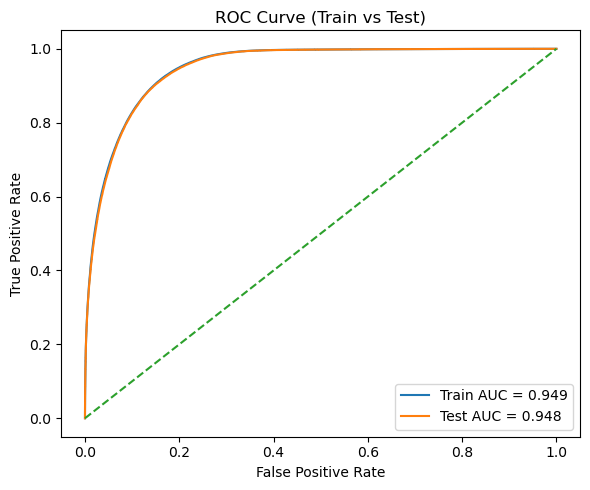

In [17]:
from sklearn.metrics import roc_curve, auc

pred_test = model.predict(X_test)
proba_test = model.predict_proba(X_test)[:, 1]

pred_train = model.predict(X_train)
proba_train = model.predict_proba(X_train)[:, 1]

print("TEST PERFORMANCE")
print(classification_report(y_test, pred_test, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_test))

fpr_test, tpr_test, _ = roc_curve(y_test, proba_test)
auc_test = auc(fpr_test, tpr_test)

fpr_train, tpr_train, _ = roc_curve(y_train, proba_train)
auc_train = auc(fpr_train, tpr_train)

fig = plt.figure(figsize=(6,5))

plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc_test:.3f}")

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Train vs Test)")
plt.legend()

plt.tight_layout()
plt.show()

Using annual means, the area under the testing curve was 0.897 as opposed to 0.949 using seasonal means.

## Output Distributions

Plot the distribution of the model output probabilities for both classes.

This gives a direct view of how confidently the classifier separates the two regimes.
Separate panels are shown for the training and testing data so that the model behaviour can be compared between the two.

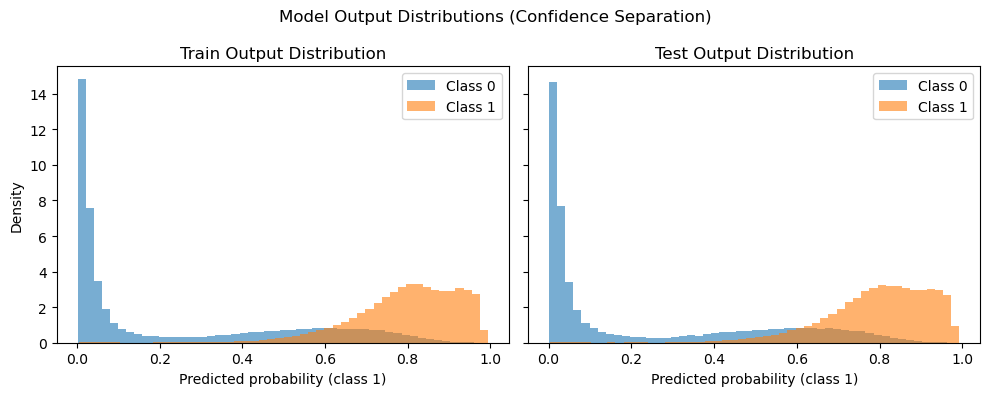

In [18]:
proba_train = model.predict_proba(X_train)[:, 1]
proba_test  = model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

axes[0].hist(
    proba_train[y_train == 0],
    bins=50,
    alpha=0.6,
    density=True,
    label="Class 0"
)
axes[0].hist(
    proba_train[y_train == 1],
    bins=50,
    alpha=0.6,
    density=True,
    label="Class 1"
)
axes[0].set_title("Train Output Distribution")
axes[0].set_xlabel("Predicted probability (class 1)")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(
    proba_test[y_test == 0],
    bins=50,
    alpha=0.6,
    density=True,
    label="Class 0"
)
axes[1].hist(
    proba_test[y_test == 1],
    bins=50,
    alpha=0.6,
    density=True,
    label="Class 1"
)
axes[1].set_title("Test Output Distribution")
axes[1].set_xlabel("Predicted probability (class 1)")
axes[1].legend()

plt.suptitle("Model Output Distributions (Confidence Separation)")
plt.tight_layout()
plt.show()

## Feature Importance

Permutation importance is used to see which variables and seasons the model relies on most strongly.

Each feature is shuffled and the drop in model performance is measured.

Because each original variable is now split by season, this allows me to see not only which physical variables matter most, but also which seasons contain the strongest signal.

In [19]:
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=5,
    random_state=1,
    scoring="roc_auc"
)

imp_df = pd.DataFrame({
    "feature": model_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=True)

display(imp_df.sort_values("importance_mean", ascending=False))

,feature,importance_mean,importance_std
22,u_current_JJA,0.225796,0.000788
18,qnet_JJA,0.127019,0.000186
20,u_current_DJF,0.109513,0.000282
23,u_current_SON,0.082139,0.000775
16,qnet_DJF,0.068706,0.000129
19,qnet_SON,0.045326,0.000109
15,thetao_SON,0.035370,0.000287
7,sst_SON,0.032742,0.000255
13,thetao_MAM,0.032659,0.000385
9,salinity_MAM,0.032124,0.000431


## Visualising Feature Importance

Plot the permutation importances as a bar chart to show which variables contribute most to the classification.

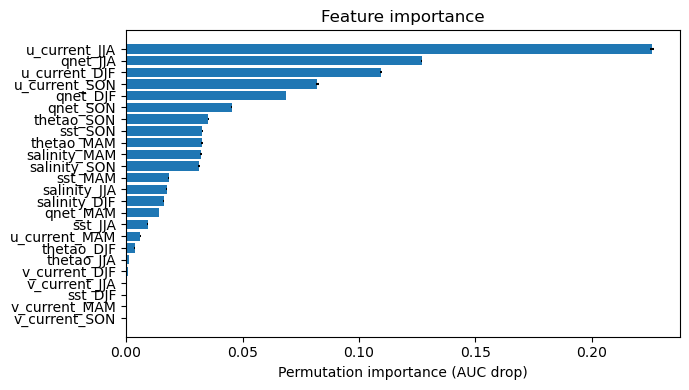

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp_df["feature"], imp_df["importance_mean"], xerr=imp_df["importance_std"])
ax.set_xlabel("Permutation importance (AUC drop)")
ax.set_title("Feature importance")
plt.tight_layout()
plt.show()

## Correlation Matrix

Calculate the Pearson correlation matrix between the seasonal input variables.

This helps identify whether some predictors contain similar information:
- across different physical variables
- across different seasons of the same variable

This is useful for checking redundancy in the expanded 24-feature dataset.

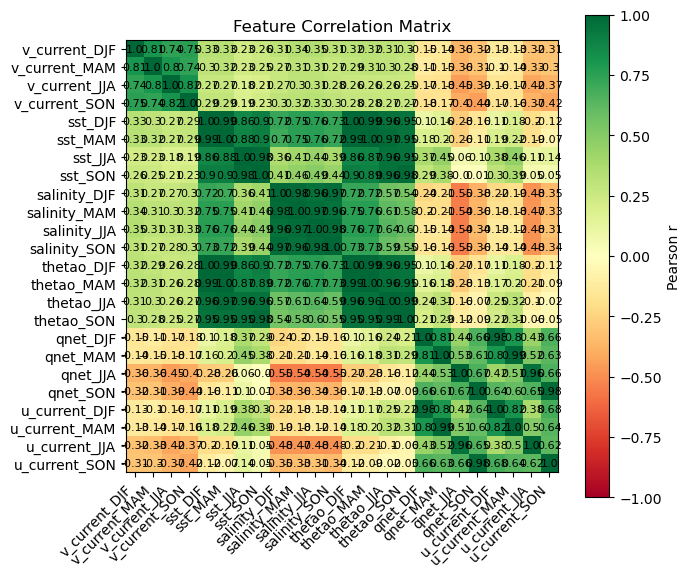

In [21]:
corr = X.corr().round(2)

fig = plt.figure(figsize=(7,6))

im = plt.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, label="Pearson r")

labels = corr.columns
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, corr.iloc[i, j],
                 ha="center", va="center", fontsize=8)

plt.title("Feature Correlation Matrix")
plt.tight_layout()

plt.show()

## Feature Distributions

Plot histograms of each seasonal feature before and after the threshold year.

This gives a simple view of how the two regimes differ in each variable and season individually.

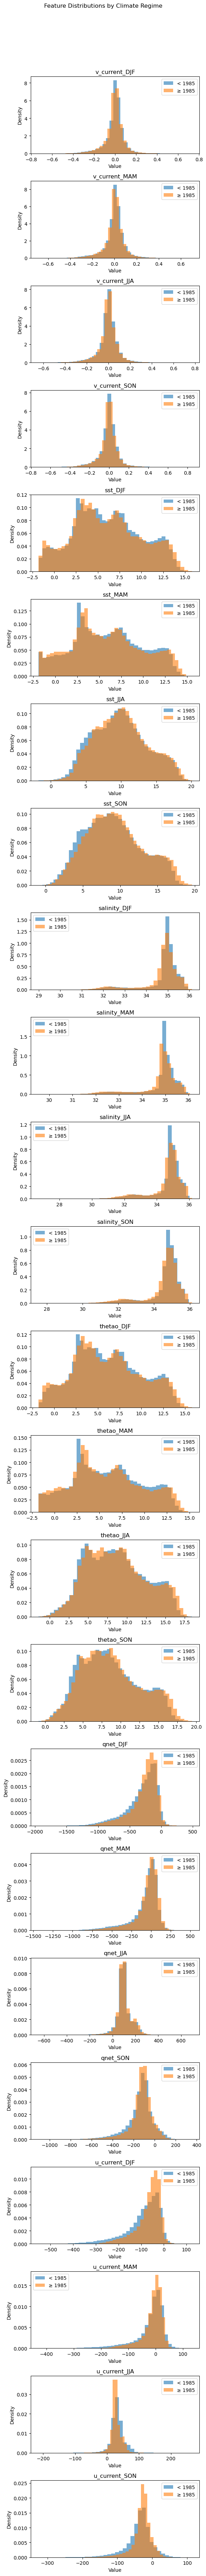

In [22]:
features = feature_cols
n = len(features)

fig, axes = plt.subplots(n, 1, figsize=(6, 3*n), sharex=False)

if n == 1:
    axes = [axes]

for i, f in enumerate(features):

    axes[i].hist(
        df[df["target"] == 0][f],
        bins=40,
        alpha=0.6,
        label=f"< {MID_YEAR}",
        density=True
    )

    axes[i].hist(
        df[df["target"] == 1][f],
        bins=40,
        alpha=0.6,
        label=f"≥ {MID_YEAR}",
        density=True
    )

    axes[i].set_title(f)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle("Feature Distributions by Climate Regime", y=1.02)
plt.tight_layout()

plt.show()

## Regional Mean Trends

Calculate the annual regional mean of each seasonal feature and plot them as time series.

A linear trend is fitted to each variable and season, and the uncertainty on the trend is shown with a 1-sigma band.

This makes it possible to compare how the long-term behaviour differs by both variable and season.

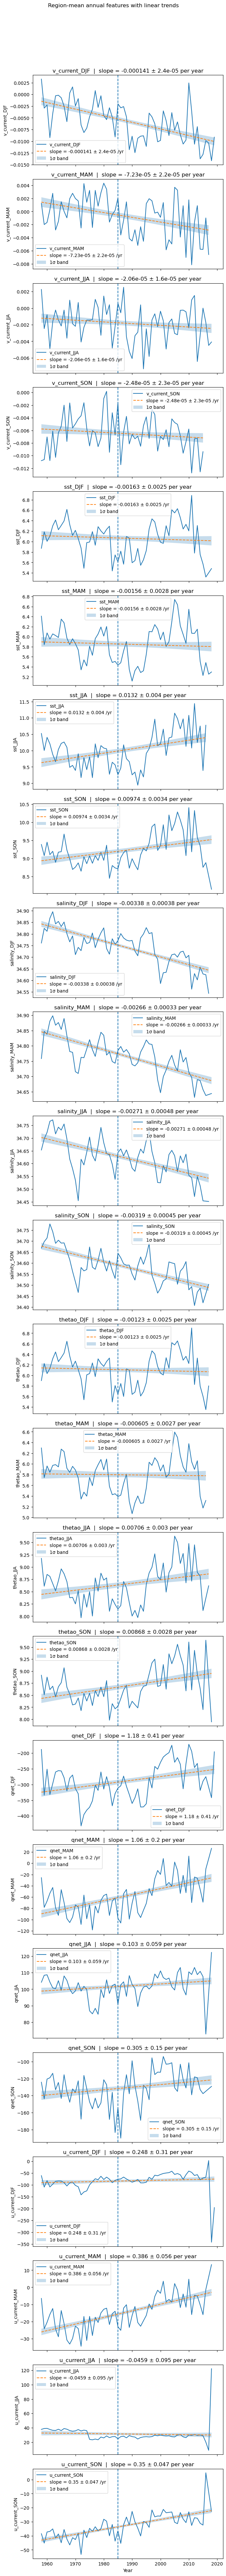

In [23]:
from scipy.stats import linregress
import numpy as np

annual_mean_df = ds_features.mean(dim=spatial_dims).to_dataframe().reset_index()

features_to_plot = [col for col in feature_cols if col in annual_mean_df.columns]
n = len(features_to_plot)

fig, axes = plt.subplots(n, 1, figsize=(7, 3.2*n), sharex=True)

if n == 1:
    axes = [axes]

for ax, col in zip(axes, features_to_plot):

    x = annual_mean_df["year"].values.astype(float)
    y = annual_mean_df[col].values.astype(float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    res = linregress(x, y)

    y_fit = res.intercept + res.slope * x

    residuals = y - y_fit
    npts = len(x)
    s = np.sqrt(np.sum(residuals**2) / (npts - 2))

    x_mean = np.mean(x)
    Sxx = np.sum((x - x_mean)**2)

    sigma_y = s * np.sqrt(1/npts + (x - x_mean)**2 / Sxx)

    ax.plot(x, y, label=col)
    ax.plot(x, y_fit, "--", label=f"slope = {res.slope:.3g} ± {res.stderr:.2g} /yr")

    ax.fill_between(
        x,
        y_fit - sigma_y,
        y_fit + sigma_y,
        alpha=0.25,
        label="1σ band"
    )

    ax.axvline(MID_YEAR, linestyle="--")

    ax.set_title(f"{col}  |  slope = {res.slope:.3g} ± {res.stderr:.2g} per year")
    ax.set_ylabel(col)
    ax.legend()

axes[-1].set_xlabel("Year")

plt.suptitle("Region-mean annual features with linear trends", y=1.02)
plt.tight_layout()

plt.show()